# Credit Card Fraud Detection - K-Nearest Neighbor(KNN)

## Importing the Dependencies

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt

%matplotlib inline

In [2]:
# loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv('/kaggle/input/credit-card-balanced-dataset/creditcard_2023.csv')

In [3]:
# first 5 rows of the dataset
credit_card_data.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [4]:
credit_card_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,568630.0,2.843145e+05,164149.486121,0.000000,142157.250000,284314.500000,426471.750000,568629.000000
V1,568630.0,-5.118237e-17,1.000001,-3.495584,-0.565286,-0.093638,0.832658,2.229046
V2,568630.0,-1.023647e-16,1.000001,-49.966572,-0.486678,-0.135894,0.343555,4.361865
V3,568630.0,1.023647e-16,1.000001,-3.183760,-0.649299,0.000353,0.628538,14.125834
V4,568630.0,0.000000e+00,1.000001,-4.951222,-0.656020,-0.073762,0.707005,3.201536
V5,568630.0,2.559118e-17,1.000001,-9.952786,-0.293496,0.081088,0.439737,42.716891
V6,568630.0,2.559118e-17,1.000001,-21.111108,-0.445871,0.078718,0.497788,26.168402
V7,568630.0,0.000000e+00,1.000001,-4.351839,-0.283533,0.233366,0.525955,217.873038
V8,568630.0,0.000000e+00,1.000001,-10.756342,-0.192257,-0.114524,0.047299,5.958040
V9,568630.0,0.000000e+00,1.000001,-3.751919,-0.568745,0.092526,0.559262,20.270062


In [5]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [6]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
print("Balanced Dataset")
class_counts = credit_card_data['Class'].value_counts()
class_counts

Balanced Dataset


Class
0    284315
1    284315
Name: count, dtype: int64

In [8]:
# Separate the two classes
class_0 = credit_card_data[credit_card_data['Class'] == 0]
class_1 = credit_card_data[credit_card_data['Class'] == 1]

# Downsample class 0 to 500 samples
class_0_downsampled = class_0.sample(n=1000, random_state=42)
class_1_downsampled = class_1.sample(n=1000, random_state=42)

# Combine the downsampled class 0 with class 1
df_balanced = pd.concat([class_0_downsampled, class_1_downsampled], axis=0)

# Shuffle the new DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new class distribution
print("Downsample Balance Data")
print(df_balanced['Class'].value_counts())


Downsample Balance Data
Class
1    1000
0    1000
Name: count, dtype: int64


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <Ax

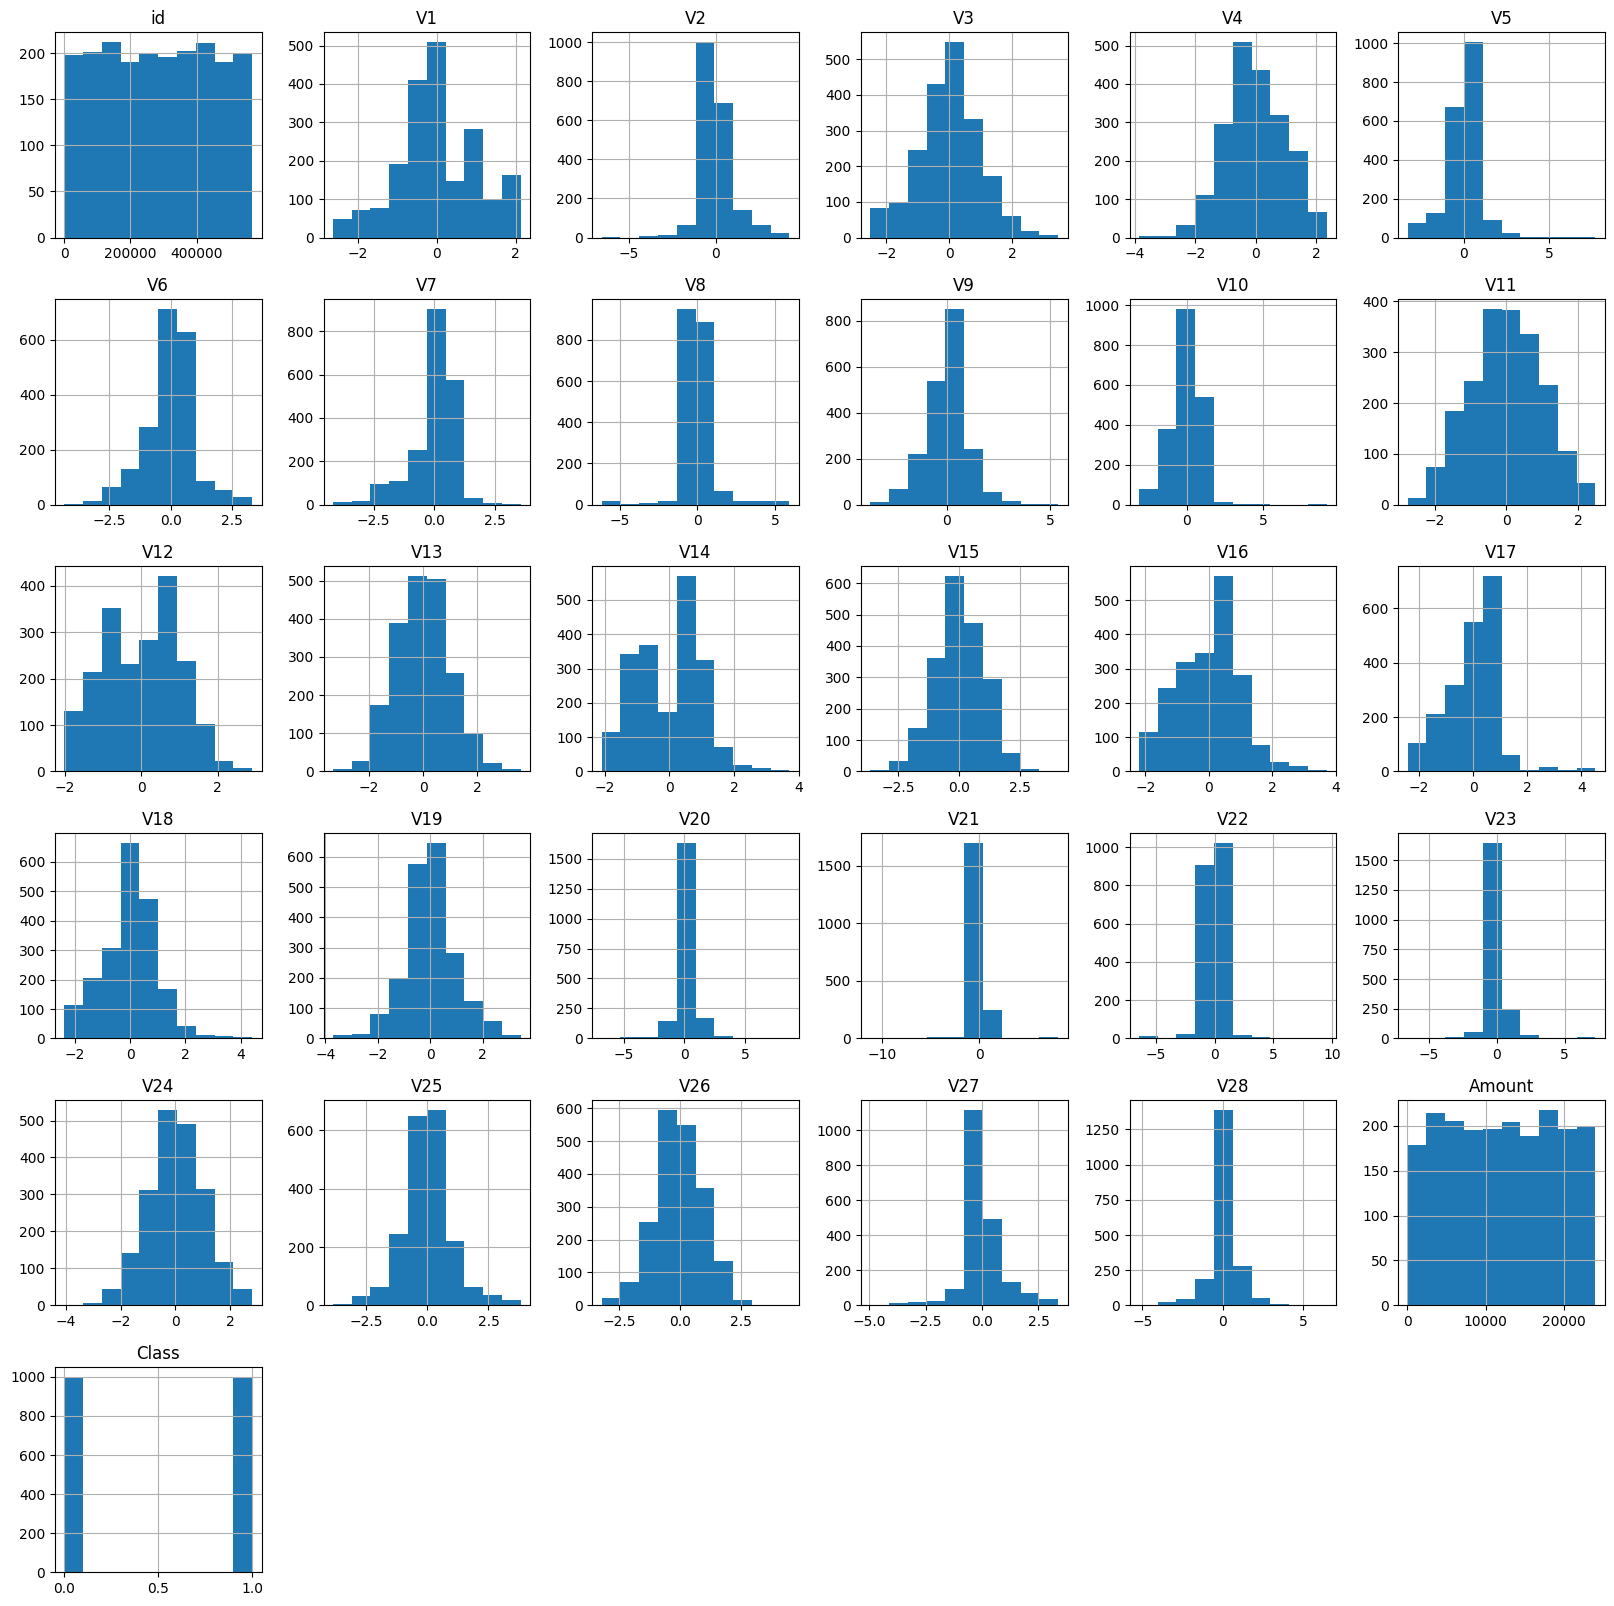

In [9]:
df_balanced.hist(figsize=(20,20))

In [10]:
# sns.pairplot(df_balanced, hue='Class',kind = 'scatter')

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()

In [13]:

X = pd.DataFrame(scaler.fit_transform(df_balanced.drop(["Class"],axis = 1)))
y = df_balanced.Class

In [14]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.537590,0.287145,-0.173326,1.703629,0.434924,0.050540,1.188770,0.078485,-0.479183,-0.089815,...,0.367178,-0.469351,0.739843,-0.129268,0.402349,0.941726,0.753820,-0.142992,0.297527,-0.711036
1,-0.882099,0.987786,-0.388634,0.528390,-0.135157,0.393568,0.670176,0.541284,-0.157882,0.633137,...,-0.285460,-0.192173,-0.162814,-0.260111,-1.232270,1.269380,-0.608061,-0.218483,-0.126043,1.340490
2,1.045919,0.368653,0.435774,-0.425130,0.740937,2.467531,0.440899,1.040036,-0.284421,-0.684845,...,-0.387353,0.025424,-0.799334,-0.540973,-1.596139,1.265083,0.690183,0.051800,0.872471,-1.050911
3,-1.352797,-0.052601,-0.179599,1.624800,-0.134696,0.403068,0.767492,0.838881,-0.130343,0.190031,...,-0.016611,-0.154203,-0.039320,-0.364429,-0.718683,0.801596,-0.206345,-0.160395,0.036108,-1.643797
4,1.145977,-1.433487,1.516467,-1.469082,0.786877,-1.490480,-1.726825,-1.257266,1.628875,-0.656596,...,0.718481,0.217768,-0.753648,-0.088393,-0.058285,0.838735,-0.599530,1.427710,0.442941,-0.166624


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
knn = KNeighborsClassifier(n_neighbors=3)

In [19]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [20]:
pred = knn.predict(X_test)

In [21]:
from sklearn.metrics import classification_report,confusion_matrix

In [22]:
print(confusion_matrix(y_test,pred))

[[192   5]
 [  1 202]]


In [23]:
print("When K = 3:")
print(classification_report(y_test,pred))

When K = 3:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       197
           1       0.98      1.00      0.99       203

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



In [24]:
for i in range(1,20):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    print("Confusion Matrix For k = :",i)
    print(confusion_matrix(y_test,pred_i))
    print("When K = :",i)
    print(classification_report(y_test,pred_i))

Confusion Matrix For k = : 1
[[190   7]
 [  0 203]]
When K = : 1
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       197
           1       0.97      1.00      0.98       203

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix For k = : 2
[[196   1]
 [  4 199]]
When K = : 2
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       197
           1       0.99      0.98      0.99       203

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

Confusion Matrix For k = : 3
[[192   5]
 [  1 202]]
When K = : 3
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       197
           1       0.98      1.00      0.9

In [25]:
error_rate = []

# Will take some time
for i in range(1,20):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

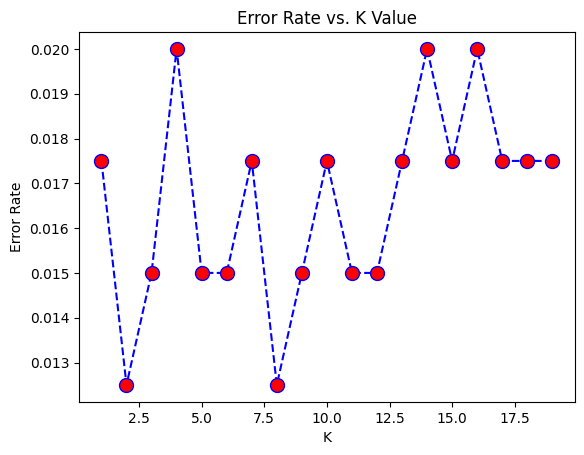

In [26]:
#### plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [27]:
#Orginal K=1
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH k=3')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH k=3


[[192   5]
 [  1 202]]


              precision    recall  f1-score   support

           0       0.99      0.97      0.98       197
           1       0.98      1.00      0.99       203

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



In [28]:
#Orginal K=4
knn = KNeighborsClassifier(n_neighbors=4)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH k=4')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH k=4


[[194   3]
 [  5 198]]


              precision    recall  f1-score   support

           0       0.97      0.98      0.98       197
           1       0.99      0.98      0.98       203

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



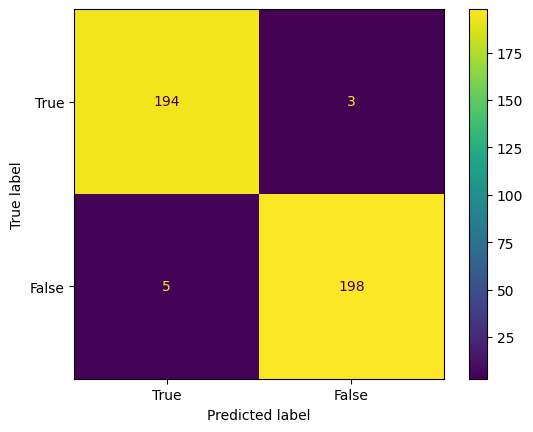

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, pred)
vis = ConfusionMatrixDisplay(confusion_matrix = conf_matrix,display_labels = [True,False])
vis.plot()
plt.grid(False)
plt.show()

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <Ax

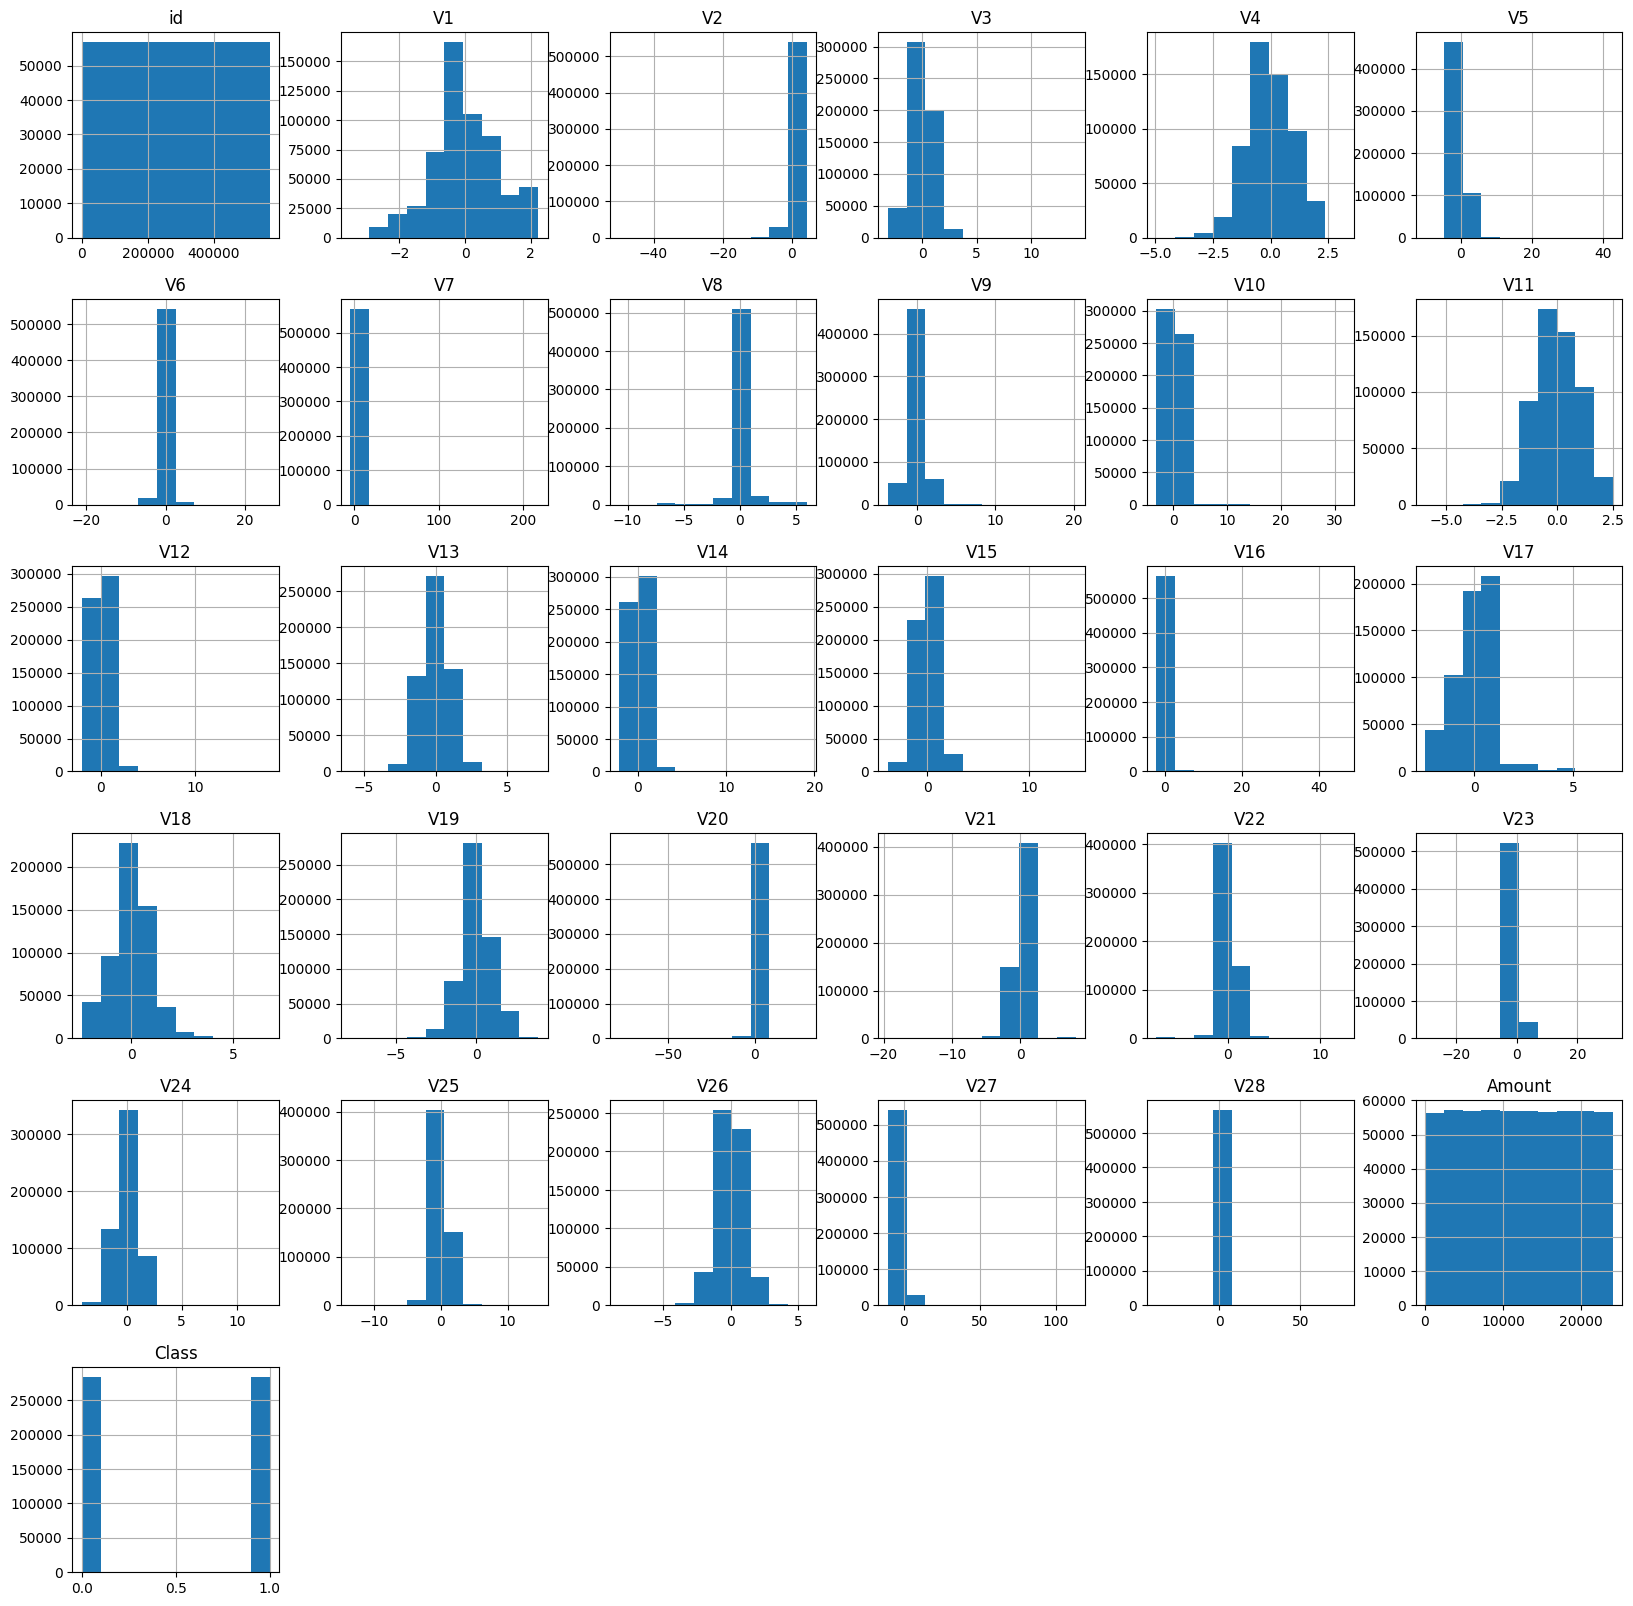

In [30]:
# 
credit_card_data.hist(figsize=(20,20))

In [31]:
# sns.pairplot(credit_card_data, hue='Class')

## standardize the variables

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [34]:

X = pd.DataFrame(scaler.fit_transform(credit_card_data.drop(["Class"],axis = 1)))
y = credit_card_data.Class

In [35]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-1.732048,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,0.091202,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,0.858447
1,-1.732042,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.233984,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,-0.796369
2,-1.732036,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,0.361652,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,-1.377011
3,-1.732029,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.378223,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,-0.962119
4,-1.732023,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,0.247237,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,0.323285


## Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

## Using KNN

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
knn = KNeighborsClassifier(n_neighbors=2)

In [40]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=2)

In [41]:
pred = knn.predict(X_test)

## Predictions and Evaluations

In [42]:
from sklearn.metrics import classification_report,confusion_matrix

In [43]:
print(confusion_matrix(y_test,pred))

[[56655    29]
 [    6 57036]]


In [44]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56684
           1       1.00      1.00      1.00     57042

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [45]:
class_counts = credit_card_data['Class'].value_counts()
class_counts

Class
0    284315
1    284315
Name: count, dtype: int64

In [46]:
error_rate = []

# Will take some time
for i in range(1,20):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

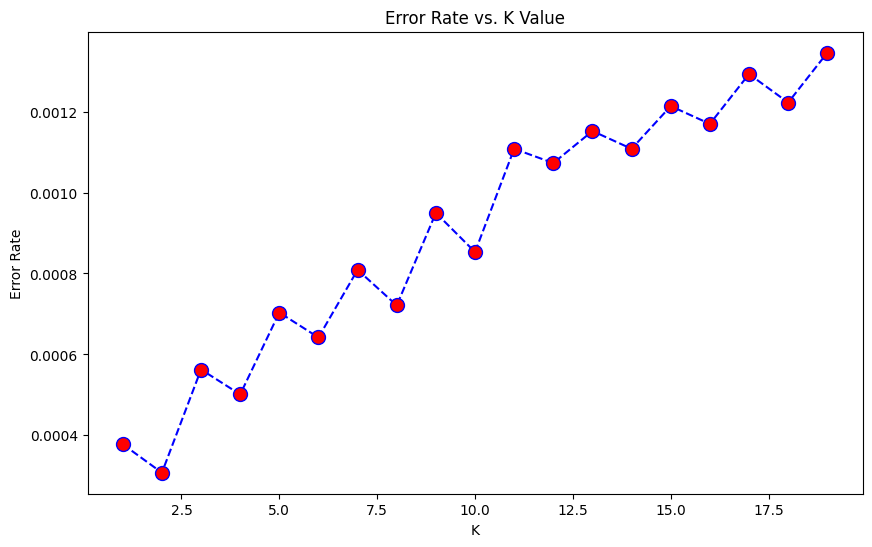

In [47]:
plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [50]:
#Orginal K=1
knn = KNeighborsClassifier(n_neighbors=2)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH k=2')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH k=2


[[56655    29]
 [    6 57036]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56684
           1       1.00      1.00      1.00     57042

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



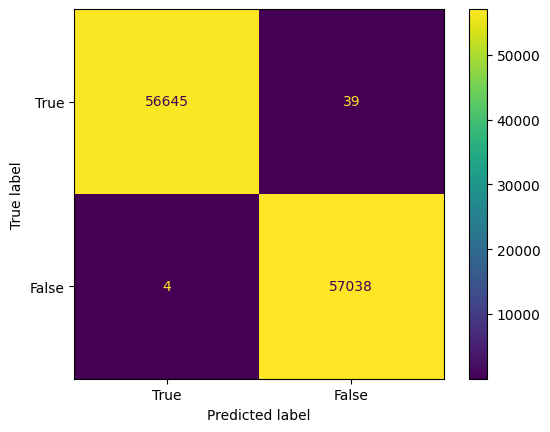

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, pred)
vis = ConfusionMatrixDisplay(confusion_matrix = conf_matrix,display_labels = [True,False])
vis.plot()
plt.grid(False)
plt.show()